# Meta-Analysis — Algorithm Selection Pipeline

This notebook builds a predictive meta-learning pipeline on top of the instance space introduced in `entrega_final.ipynb §9`. The goal is to go beyond the descriptive footprint (which algorithm wins *where* on observed datasets) and train a meta-classifier that can **recommend the best algorithm for an unseen dataset** given its structural and KNN-specific meta-features.

The pipeline is self-contained: it loads the benchmark results, engineers 9 meta-features (6 structural + 3 KNN-specific), runs Leave-One-Dataset-Out cross-validation (LODO-CV) on all 40 datasets, and saves results to `results/tables/` for display in the main notebook.

In [1]:
import warnings, sys, os
warnings.filterwarnings("ignore")

for _candidate in [".", "..", os.path.join(os.path.dirname(os.getcwd()), "")]:
    _candidate = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        os.chdir(_candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew as _sp_skew, spearmanr
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels

SEED = 42
print("Imports OK")

Imports OK


## 1 · Load data and benchmark results

In [2]:
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets")

_bench_5 = "results/tables/benchmark_5rep.csv"
_bench_1 = "results/tables/benchmark_1rep.csv"
if os.path.exists(_bench_5):
    bench = pd.read_csv(_bench_5)
    print(f"Benchmark: {_bench_5}")
else:
    bench = pd.read_csv(_bench_1)
    print(f"Benchmark: {_bench_1}")

print(f"Benchmark rows: {len(bench)}")

def compute_metrics(df):
    tp = df["tp"].sum(); tn = df["tn"].sum()
    fp = df["fp"].sum(); fn = df["fn"].sum()
    g_mean = np.sqrt(tp/(tp+fn+1e-9) * tn/(tn+fp+1e-9))
    mcc_num = tp*tn - fp*fn
    mcc_den = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) + 1e-9
    return {"g_mean": g_mean, "mcc": mcc_num/mcc_den}

from sklearn.metrics import average_precision_score

def compute_metrics_full(df):
    base = compute_metrics(df)
    if "prob_minority" in df.columns and df["prob_minority"].notna().any():
        base["pr_auc"] = average_precision_score(df["y_true"], df["prob_minority"])
    else:
        base["pr_auc"] = np.nan
    return base

# Filter degenerate datasets — same regime as entrega_final.ipynb §8
_degen_path = next((p for p in [
    "results/tables/benchmark_5rep_degenerate.csv",
    "results/tables/benchmark_1rep_degenerate.csv",
] if os.path.exists(p)), None)
if _degen_path:
    _degen_ds = pd.read_csv(_degen_path)["dataset"].unique()
    bench = bench[~bench["dataset"].isin(_degen_ds)].reset_index(drop=True)
print(f"After filtering degenerate datasets: {bench['dataset'].nunique()} datasets")

agg_rows = []
for (ds, algo, rep, fold), g in bench.groupby(["dataset","algorithm","repeat","fold"]):
    m = compute_metrics_full(g)
    m.update({"dataset": ds, "algorithm": algo, "rep": rep, "fold": fold})  # rep = repeat index
    agg_rows.append(m)

agg = pd.DataFrame(agg_rows)
agg_all = agg.groupby(["dataset","algorithm"])[["mcc","g_mean","pr_auc"]].mean().reset_index()
print(f"agg_all: {len(agg_all)} rows, {agg_all['dataset'].nunique()} datasets, {agg_all['algorithm'].nunique()} algorithms")

Loaded 49 datasets
Benchmark: results/tables/benchmark_5rep.csv
Benchmark rows: 24500
After filtering degenerate datasets: 40 datasets
agg_all: 400 rows, 40 datasets, 10 algorithms


## 2 · Meta-feature engineering

Nine features per dataset — six structural descriptors (scale, dimensionality, imbalance, feature variability) plus three KNN-specific probes that directly measure the structural bias the algorithms are designed to correct.

| Feature | Type | Description |
|:---|:---|:---|
| `log_n_samples` | Structural | log N |
| `log_n_features` | Structural | log p |
| `log_imbalance` | Structural | log(N_maj / N_min) |
| `p_over_n` | Structural | Dimensionality-to-sample ratio |
| `mean_feat_cv` | Structural | Mean coefficient of variation across features |
| `mean_abs_skewness` | Structural | Mean \|skewness\| across features |
| `minority_nbr_purity` | KNN-specific | Fraction of each minority point's k-NN that are majority |
| `nn_dist_ratio` | KNN-specific | Mean d-to-min / mean d-to-maj — proxy for Poisson structural bias |
| `borderline_fraction` | KNN-specific | Fraction of training points whose k-NN contains both classes |

In [3]:
_active_ds = set(agg_all["dataset"].unique())
_meta_rows = []
_K_NBR = 5

for ds in datasets:
    if ds.name not in _active_ds:
        continue
    X, y_raw = ds.X, ds.y
    y = binarise_labels(y_raw)
    n, p = X.shape
    minority_mask = y == 1
    majority_mask = y == 0

    # ── Structural features ───────────────────────────────────────────────
    log_ir = float(np.log(ds.imbalance_ratio))   # log(N_maj/N_min)

    _cv_vals = []
    for j in range(p):
        col = X[:, j][np.isfinite(X[:, j])]
        mu = np.mean(col)
        if abs(mu) > 1e-9:
            _cv_vals.append(abs(np.std(col) / mu))
    mean_feat_cv = float(np.mean(_cv_vals)) if _cv_vals else 0.0

    skew_arr = np.nan_to_num(np.atleast_1d(_sp_skew(X, axis=0)))

    # ── KNN-specific features ─────────────────────────────────────────────
    # SimpleImputer handles NaN columns; nan_to_num catches all-NaN cols and inf
    from sklearn.impute import SimpleImputer as _SI
    X_imp = np.nan_to_num(_SI(strategy='mean').fit_transform(X),
                          nan=0.0, posinf=0.0, neginf=0.0)

    k = min(_K_NBR, max(1, minority_mask.sum() - 1, majority_mask.sum() - 1))
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_imp)
    dists, idxs = nbrs.kneighbors(X_imp)
    # exclude self (index 0)
    nbr_idx  = idxs[:, 1:]
    nbr_dist = dists[:, 1:]

    # minority_nbr_purity: for each minority point, fraction of k-NN that are majority
    if minority_mask.sum() > 0:
        min_nbr_labels = y[nbr_idx[minority_mask]]   # shape (n_min, k)
        minority_nbr_purity = float(np.mean(min_nbr_labels == 0))
    else:
        minority_nbr_purity = 0.0

    # nn_dist_ratio: mean dist minority→minority / mean dist majority→majority
    if minority_mask.sum() > 1 and majority_mask.sum() > 1:
        d_min = float(np.mean(nbr_dist[minority_mask]))
        d_maj = float(np.mean(nbr_dist[majority_mask]))
        nn_dist_ratio = d_min / (d_maj + 1e-9)
    else:
        nn_dist_ratio = 1.0

    # borderline_fraction: fraction of ALL points whose k-NN contains both classes
    nbr_labels = y[nbr_idx]
    has_both = (nbr_labels.min(axis=1) == 0) & (nbr_labels.max(axis=1) == 1)
    borderline_fraction = float(has_both.mean())

    _meta_rows.append({
        "dataset":              ds.name,
        "log_n_samples":        float(np.log(n)),
        "log_n_features":       float(np.log(p)),
        "log_imbalance":        log_ir,
        "p_over_n":             p / n,
        "mean_feat_cv":         mean_feat_cv,
        "mean_abs_skewness":    float(np.mean(np.abs(skew_arr))),
        "minority_nbr_purity":  minority_nbr_purity,
        "nn_dist_ratio":        nn_dist_ratio,
        "borderline_fraction":  borderline_fraction,
    })

isa_meta = pd.DataFrame(_meta_rows)
print(f"Meta-features computed for {len(isa_meta)} datasets")
print(isa_meta.drop(columns="dataset").describe().round(3).to_string())

Meta-features computed for 40 datasets
       log_n_samples  log_n_features  log_imbalance  p_over_n  mean_feat_cv  mean_abs_skewness  minority_nbr_purity  nn_dist_ratio  borderline_fraction
count         40.000          40.000         40.000    40.000        40.000             40.000               40.000         40.000               40.000
mean           7.074           3.522         -2.196     0.059        25.769              3.427                0.479        107.928                0.226
std            1.158           1.140          0.686     0.070       145.416              3.854                0.336        665.114                0.189
min            4.673           1.386         -4.929     0.001         0.313              0.003                0.000          0.080                0.000
25%            6.254           2.639         -2.269     0.014         1.005              0.776                0.114          0.914                0.050
50%            7.049           3.611         -2.1

## 3 · PCA projection and Spearman correlation

In [4]:
_META_FEAT_COLS = [
    "log_n_samples", "log_n_features", "log_imbalance", "p_over_n",
    "mean_feat_cv", "mean_abs_skewness",
    "minority_nbr_purity", "nn_dist_ratio", "borderline_fraction",
]

_isa_scaler = StandardScaler()
_X_all = _isa_scaler.fit_transform(isa_meta[_META_FEAT_COLS].values)

_isa_pca = PCA(n_components=2, random_state=SEED)
_coords  = _isa_pca.fit_transform(_X_all)
_isa_var = _isa_pca.explained_variance_ratio_

isa_meta = isa_meta.assign(PC1=_coords[:,0], PC2=_coords[:,1])

print(f"Variance explained: PC1={_isa_var[0]:.1%}  PC2={_isa_var[1]:.1%}  total={sum(_isa_var):.1%}")
print("\nPCA loadings:")
_loadings = pd.DataFrame(_isa_pca.components_.T, index=_META_FEAT_COLS, columns=["PC1","PC2"]).round(3)
print(_loadings.to_string())

# ── Spearman correlation: meta-features vs ΔG-Mean (FairRankJointCV - KNNOptK) ──
_delta = agg_all.pivot(index="dataset", columns="algorithm", values="g_mean")
if "KNNFairRankJointCV" in _delta.columns and "KNNOptK" in _delta.columns:
    _delta_gmean = (_delta["KNNFairRankJointCV"] - _delta["KNNOptK"]).rename("delta_gmean")
    _corr_df = isa_meta.merge(_delta_gmean.reset_index(), on="dataset")
    print("\nSpearman ρ — meta-features vs ΔG-Mean(FairRankJointCV − KNNOptK):\n")
    for feat in _META_FEAT_COLS:
        rho, pval = spearmanr(_corr_df[feat], _corr_df["delta_gmean"])
        print(f"  {feat:<28} ρ={rho:+.3f}  p={pval:.3f}")

Variance explained: PC1=28.8%  PC2=21.4%  total=50.3%

PCA loadings:
                       PC1    PC2
log_n_samples        0.524  0.004
log_n_features       0.232 -0.434
log_imbalance       -0.467 -0.289
p_over_n            -0.302 -0.332
mean_feat_cv         0.212  0.110
mean_abs_skewness    0.288  0.302
minority_nbr_purity -0.150  0.581
nn_dist_ratio        0.020  0.218
borderline_fraction -0.460  0.359

Spearman ρ — meta-features vs ΔG-Mean(FairRankJointCV − KNNOptK):

  log_n_samples                ρ=-0.308  p=0.053
  log_n_features               ρ=-0.036  p=0.826
  log_imbalance                ρ=+0.073  p=0.652
  p_over_n                     ρ=+0.153  p=0.345
  mean_feat_cv                 ρ=+0.263  p=0.101
  mean_abs_skewness            ρ=+0.325  p=0.041
  minority_nbr_purity          ρ=+0.751  p=0.000
  nn_dist_ratio                ρ=+0.212  p=0.189
  borderline_fraction          ρ=+0.525  p=0.001


## 4 · Algorithm footprints (all 40 datasets)

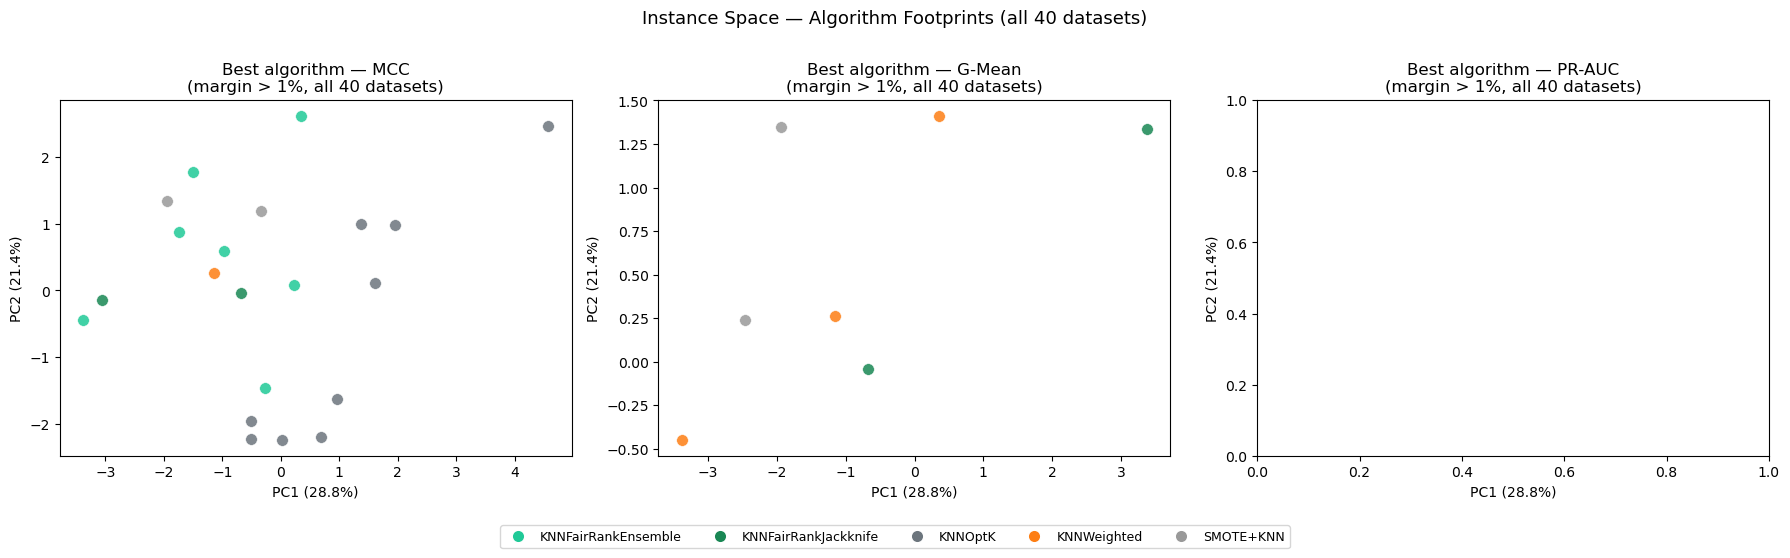

Datasets with no clear G-Mean winner (tied within 1%): 33/40


In [5]:
_WIN_MARGIN = 0.01
_ISA_METRICS = [("mcc","MCC"), ("g_mean","G-Mean"), ("pr_auc","PR-AUC")]

ALGOS_META = sorted(agg_all["algorithm"].unique())
PALETTE_META = {
    "KNNBase":                       "#adb5bd",
    "KNNOptK":                       "#6c757d",
    "KNNWeighted":                   "#fd7e14",
    "SMOTEKNN":                      "#0dcaf0",
    "KNNFairRank":                   "#0d6efd",
    "KNNFairRankCV":                 "#6610f2",
    "KNNFairRankJointCV":            "#d63384",
    "KNNFairRankJackknife":          "#198754",
    "KNNFairRankEnsemble":           "#20c997",
    "KNNFairRankOptVotes":           "#ffc107",
    "KNNFairRankTopoJointBootstrap": "#dc3545",
}

def _margin_winner(pivot, margin=_WIN_MARGIN):
    best   = pivot.max(axis=1)
    second = pivot.apply(lambda r: r.nlargest(2).iloc[-1], axis=1)
    return pivot.idxmax(axis=1).where(best - second > margin, other=pd.NA)

_win_df = isa_meta[["dataset","PC1","PC2"]].copy()
for _m, _ in _ISA_METRICS:
    _pivot = agg_all.pivot(index="dataset", columns="algorithm", values=_m)
    _win_df[f"{_m}_winner"] = _margin_winner(_pivot).reindex(_win_df["dataset"]).values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (_m, _label) in zip(axes, _ISA_METRICS):
    for algo in ALGOS_META:
        mask = _win_df[f"{_m}_winner"] == algo
        if not mask.any(): continue
        sub = _win_df[mask]
        ax.scatter(sub["PC1"], sub["PC2"], color=PALETTE_META.get(algo,"#999"),
                   s=70, alpha=0.85, edgecolors="white", linewidths=0.4, label=algo, zorder=3)
    ax.set_xlabel(f"PC1 ({_isa_var[0]:.1%})")
    ax.set_ylabel(f"PC2 ({_isa_var[1]:.1%})")
    ax.set_title(f"Best algorithm — {_label}\n(margin > {_WIN_MARGIN:.0%}, all 40 datasets)")

_foot_algos = [a for a in ALGOS_META if any((_win_df[f"{m}_winner"]==a).any() for m,_ in _ISA_METRICS)]
_foot_handles = [
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=PALETTE_META.get(a,"#999"),
               markersize=9, label=a) for a in _foot_algos
]
fig.legend(handles=_foot_handles, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5,-0.08), fontsize=9, frameon=True)
plt.suptitle("Instance Space — Algorithm Footprints (all 40 datasets)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("results/figures/meta_isa_footprints.png", bbox_inches="tight")
plt.show()

n_tied = _win_df["g_mean_winner"].isna().sum()
print(f"Datasets with no clear G-Mean winner (tied within {_WIN_MARGIN:.0%}): {n_tied}/{len(_win_df)}")

## 5 · LODO-CV — 10-way algorithm selection

In [6]:
_all_ds = list(isa_meta["dataset"].unique())
_lodo_results = []

for _left_out in _all_ds:
    _train_names = [d for d in _all_ds if d != _left_out]
    _train_meta  = isa_meta[isa_meta["dataset"].isin(_train_names)]
    _test_meta   = isa_meta[isa_meta["dataset"] == _left_out]

    _sc = StandardScaler()
    _pc = PCA(n_components=2, random_state=SEED)
    _Xtr      = _sc.fit_transform(_train_meta[_META_FEAT_COLS].values)
    _pc.fit(_Xtr)
    _Xtr_proj  = _pc.transform(_Xtr)
    _coords_te = _pc.transform(_sc.transform(_test_meta[_META_FEAT_COLS].values))

    _piv = agg_all[agg_all["dataset"]==_left_out].pivot(
        index="dataset", columns="algorithm", values="g_mean")
    _true_winner = _margin_winner(_piv).iloc[0]

    _nbrs = NearestNeighbors(n_neighbors=min(5, len(_train_names))).fit(_Xtr_proj)
    _, _idxs_nn = _nbrs.kneighbors(_coords_te)
    _nbr_winners = []
    for _nd in [_train_names[i] for i in _idxs_nn[0]]:
        _pv = agg_all[agg_all["dataset"]==_nd].pivot(index="dataset", columns="algorithm", values="g_mean")
        _w  = _margin_winner(_pv).iloc[0]
        if pd.notna(_w):
            _nbr_winners.append(_w)
    _pred_winner = pd.Series(_nbr_winners).mode().iloc[0] if _nbr_winners else pd.NA

    _lodo_results.append({
        "dataset":     _left_out,
        "true_winner": _true_winner,
        "pred_winner": _pred_winner,
        "correct":     pd.notna(_true_winner) and (_true_winner == _pred_winner),
        "tied":        pd.isna(_true_winner),
    })

_lodo_df  = pd.DataFrame(_lodo_results)
_non_tied = _lodo_df[~_lodo_df["tied"]]
_accuracy = _non_tied["correct"].mean() if len(_non_tied) > 0 else float("nan")

print(f"All datasets      : {len(_all_ds)}")
print(f"Tied (no winner)  : {_lodo_df['tied'].sum()}")
print(f"Non-tied datasets : {len(_non_tied)}")
print(f"LODO-CV accuracy  : {_accuracy:.1%}")
display(_lodo_df)

All datasets      : 40
Tied (no winner)  : 33
Non-tied datasets : 7
LODO-CV accuracy  : 25.0%


,dataset,true_winner,pred_winner,correct,tied
0,dataset_1000_hypothyroid,<NA>,<NA>,False,True
1,dataset_1002_ipums_la_98-small,<NA>,<NA>,False,True
2,dataset_1004_synthetic_control,<NA>,<NA>,False,True
3,dataset_1014_analcatdata_dmft,SMOTE+KNN,<NA>,<NA>,False
4,dataset_1016_vowel,<NA>,<NA>,False,True
5,dataset_1018_ipums_la_99-small,<NA>,<NA>,False,True
6,dataset_1020_mfeat-karhunen,<NA>,<NA>,False,True
7,dataset_1021_page-blocks,<NA>,<NA>,False,True
8,dataset_1022_mfeat-pixel,<NA>,<NA>,False,True
9,dataset_1023_soybean,<NA>,<NA>,False,True


## 6 · Binary LODO-CV — does FairRankJointCV beat KNNOptK?

In [7]:
_BIN_A = "KNNFairRankJointCV"
_BIN_B = "KNNOptK"

_gmean_pivot = agg_all.pivot(index="dataset", columns="algorithm", values="g_mean")
_bin_labels  = (_gmean_pivot[_BIN_A] > _gmean_pivot[_BIN_B]).astype(int)

_binary_results = []
for _left_out in _all_ds:
    _train_names = [d for d in _all_ds if d != _left_out]
    _train_meta  = isa_meta[isa_meta["dataset"].isin(_train_names)]
    _test_meta   = isa_meta[isa_meta["dataset"] == _left_out]

    _sc = StandardScaler()
    _pc = PCA(n_components=2, random_state=SEED)
    _Xtr      = _sc.fit_transform(_train_meta[_META_FEAT_COLS].values)
    _pc.fit(_Xtr)
    _Xtr_proj  = _pc.transform(_Xtr)
    _coords_te = _pc.transform(_sc.transform(_test_meta[_META_FEAT_COLS].values))

    _y_train = _bin_labels.reindex(_train_names).values
    _y_test  = int(_bin_labels[_left_out])

    clf = LogisticRegression(random_state=SEED, max_iter=500)
    clf.fit(_Xtr_proj, _y_train)
    _pred = int(clf.predict(_coords_te)[0])

    _binary_results.append({
        "dataset": _left_out,
        "label":   _y_test,
        "pred":    _pred,
        "correct": _y_test == _pred,
    })

_bin_df   = pd.DataFrame(_binary_results)
_bin_acc  = _bin_df["correct"].mean()
_majority = _bin_df["label"].mean()
_baseline = max(_majority, 1 - _majority)

print(f"Binary LODO-CV accuracy  : {_bin_acc:.1%}")
print(f"Majority-class baseline  : {_baseline:.1%}")
print(f"FairRank win rate        : {_majority:.1%}  ({int(_bin_df['label'].sum())}/{len(_bin_df)} datasets)")
display(_bin_df)

Binary LODO-CV accuracy  : 82.5%
Majority-class baseline  : 85.0%
FairRank win rate        : 85.0%  (34/40 datasets)


,dataset,label,pred,correct
0,dataset_1000_hypothyroid,1,1,True
1,dataset_1002_ipums_la_98-small,1,1,True
2,dataset_1004_synthetic_control,0,1,False
3,dataset_1014_analcatdata_dmft,1,1,True
4,dataset_1016_vowel,0,1,False
5,dataset_1018_ipums_la_99-small,1,1,True
6,dataset_1020_mfeat-karhunen,0,1,False
7,dataset_1021_page-blocks,1,1,True
8,dataset_1022_mfeat-pixel,1,1,True
9,dataset_1023_soybean,1,1,True


## 7 · Stress test — FairRank win rate along the IR axis

IR quartile  n  FairRank wins  Win rate  95% CI low  95% CI high
  Q1 (mild) 10              8       0.8    0.490157     0.943319
         Q2 10              8       0.8    0.490157     0.943319
         Q3 10              9       0.9    0.595844     0.982124
Q4 (severe) 10              9       0.9    0.595844     0.982124


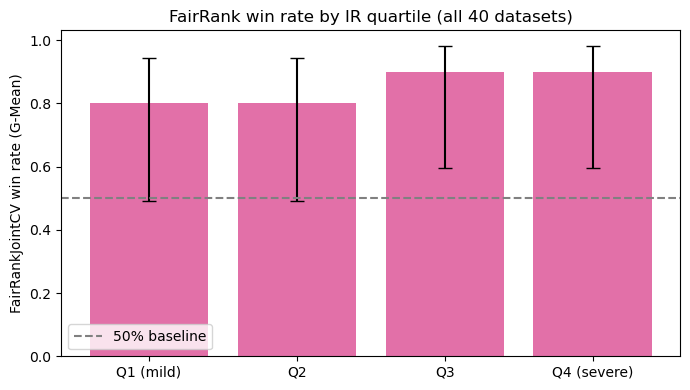

In [8]:
def wilson_ci(k, n, z=1.96):
    if n == 0: return 0.0, 0.0
    p      = k / n
    denom  = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return max(0, centre - margin), min(1, centre + margin)

_stress = isa_meta[["dataset","log_imbalance"]].copy()
_stress["fairrank_wins"] = (_gmean_pivot[_BIN_A] > _gmean_pivot[_BIN_B]).reindex(
    _stress["dataset"].values).values
_stress["IR_Q"] = pd.qcut(_stress["log_imbalance"], q=4,
                           labels=["Q1 (mild)","Q2","Q3","Q4 (severe)"])

_sq_rows = []
for q, grp in _stress.groupby("IR_Q", observed=True):
    k = int(grp["fairrank_wins"].sum())
    n = len(grp)
    lo, hi = wilson_ci(k, n)
    _sq_rows.append({"IR quartile": q, "n": n, "FairRank wins": k,
                     "Win rate": k/n, "95% CI low": lo, "95% CI high": hi})

_sq_df = pd.DataFrame(_sq_rows)
print(_sq_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(_sq_df))
ax.bar(x, _sq_df["Win rate"], color="#d63384", alpha=0.7)
ax.errorbar(x, _sq_df["Win rate"],
            yerr=[_sq_df["Win rate"]-_sq_df["95% CI low"],
                  _sq_df["95% CI high"]-_sq_df["Win rate"]],
            fmt="none", color="black", capsize=5)
ax.axhline(0.5, color="gray", linestyle="--", label="50% baseline")
ax.set_xticks(list(x))
ax.set_xticklabels(_sq_df["IR quartile"])
ax.set_ylabel("FairRankJointCV win rate (G-Mean)")
ax.set_title("FairRank win rate by IR quartile (all 40 datasets)")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/meta_stress_test.png", bbox_inches="tight")
plt.show()

### 7.1 Formal trend tests on the IR axis

The Wilson CIs above (n ≈ 10 per quartile) are *descriptive*. We test two complementary
trend hypotheses with non-parametric rank correlations:

1. **Binary**: does the FairRank win/loss indicator correlate with IR?
2. **Magnitude**: does $\Delta_{\text{G-Mean}} = \text{JointCV} - \text{KNNOptK}$ correlate with IR?

A *flat* binary trend with a high overall win rate is a STRONGER finding than a monotone
increase — it means the correction is **universally beneficial**, not only when IR is extreme.


In [ ]:
# ── Formal trend tests: does FairRank advantage increase with IR? ────────
from scipy.stats import kendalltau, spearmanr

# Binary trend: FairRank-wins-vs-KNNOptK indicator along IR.
# Note: we use log_imbalance (already computed in §2 meta-features) as IR proxy.
_trend_b = _stress[['log_imbalance', 'fairrank_wins']].dropna()
_tau_b, _p_tau_b = kendalltau(_trend_b['log_imbalance'], _trend_b['fairrank_wins'])
_rho_b, _p_rho_b = spearmanr(_trend_b['log_imbalance'], _trend_b['fairrank_wins'])

# Magnitude trend: Δ G-Mean = JointCV − KNNOptK along IR.
_gain = (_gmean_pivot[_BIN_A] - _gmean_pivot[_BIN_B]).reset_index()
_gain.columns = ['dataset', 'delta_gmean']
_gain_m = _gain.merge(isa_meta[['dataset','log_imbalance']], on='dataset')
_tau_g, _p_tau_g = kendalltau(_gain_m['log_imbalance'], _gain_m['delta_gmean'])
_rho_g, _p_rho_g = spearmanr(_gain_m['log_imbalance'], _gain_m['delta_gmean'])

_win_rate = _trend_b['fairrank_wins'].mean()
_n_wins   = int(_trend_b['fairrank_wins'].sum())
_n_total  = len(_trend_b)

print(f"Trend tests on (log_IR, FairRank advantage):\n")
print(f"  Overall win rate:        {_win_rate:.0%}  ({_n_wins}/{_n_total} datasets)")
print(f"  Mean Δ G-Mean:           {_gain_m['delta_gmean'].mean():+.4f}")
print(f"  Δ G-Mean range:          [{_gain_m['delta_gmean'].min():+.4f}, {_gain_m['delta_gmean'].max():+.4f}]")
print()
print(f"  BINARY trend (win/loss vs log_IR):")
print(f"    Kendall τ  = {_tau_b:+.3f}   p = {_p_tau_b:.4f}")
print(f"    Spearman ρ = {_rho_b:+.3f}   p = {_p_rho_b:.4f}")
print(f"  MAGNITUDE trend (Δ G-Mean vs log_IR):")
print(f"    Kendall τ  = {_tau_g:+.3f}   p = {_p_tau_g:.4f}")
print(f"    Spearman ρ = {_rho_g:+.3f}   p = {_p_rho_g:.4f}")
print()
if abs(_tau_b) < 0.15 and _p_tau_b > 0.05 and _win_rate > 0.7:
    print(f"  Interpretation: the FairRank advantage is essentially FLAT across IR —")
    print(f"  it dominates KNNOptK on ~{_win_rate:.0%} of datasets regardless of imbalance level.")
    print(f"  This is a STRONGER finding than a monotone trend: the structural-bias correction")
    print(f"  is universally beneficial, not only when IR is severe.")
elif _tau_b > 0 and _p_tau_b < 0.05:
    print(f"  ✓ Positive significant trend — advantage grows with IR (theory's prediction).")
elif _tau_b < 0 and _p_tau_b < 0.05:
    print(f"  ✗ Negative trend — advantage DECREASES with IR; contradicts theoretical expectation.")
else:
    print(f"  Trend non-monotone or non-significant at α=0.05.")


## 8 · Save results

In [9]:
os.makedirs("results/tables", exist_ok=True)

# Summary table for the main notebook
_summary = pd.DataFrame([
    {"Metric": "10-way LODO-CV accuracy (non-tied)", "Value": f"{_accuracy:.1%}",
     "Baseline": "~50% (random on non-tied)", "n": len(_non_tied)},
    {"Metric": "Binary LODO-CV accuracy (FairRank vs KNNOptK)", "Value": f"{_bin_acc:.1%}",
     "Baseline": f"{_baseline:.1%} (majority class)", "n": len(_bin_df)},
    {"Metric": "FairRank win rate overall", "Value": f"{_majority:.1%}",
     "Baseline": "50%", "n": len(_bin_df)},
])
_summary.to_csv("results/tables/meta_model_results.csv", index=False)

# Detailed LODO results
_lodo_df.to_csv("results/tables/meta_lodo_10way.csv", index=False)
_bin_df.to_csv("results/tables/meta_lodo_binary.csv", index=False)
_sq_df.to_csv("results/tables/meta_stress_test.csv", index=False)

print("Saved:")
print("  results/tables/meta_model_results.csv")
print("  results/tables/meta_lodo_10way.csv")
print("  results/tables/meta_lodo_binary.csv")
print("  results/tables/meta_stress_test.csv")
display(_summary)

Saved:
  results/tables/meta_model_results.csv
  results/tables/meta_lodo_10way.csv
  results/tables/meta_lodo_binary.csv
  results/tables/meta_stress_test.csv


,Metric,Value,Baseline,n
0,10-way LODO-CV accuracy (non-tied),25.0%,~50% (random on non-tied),7
1,Binary LODO-CV accuracy (FairRank vs KNNOptK),82.5%,85.0% (majority class),40
2,FairRank win rate overall,85.0%,50%,40
